# 인공신경망
Artificial Neural Network(ANN)

# FashionMNIST 데이터셋

- MNIST 는
  - 손글씨 이미지 데이터셋
  - 0 ~ 9 까지의 숫자 손글씨

- **FashionMNIST** 는 숫자 대신 패션 아이템 이미지로 구성

![](https://www.researchgate.net/publication/373046669/figure/fig1/AS:11431281180809965@1691723436709/The-FashionMNIST-dataset-consists-of-10-classes-of-monochrome-clothing-items-and-is.png)

  - 많은 딥러닝 라이브러리에서 이 데이터를 가져올수 있도록 제공함

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
import tensorflow as tf

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()
# TF 로 하여금 deterministic 하게 동작하도록 설정함
# -> 동일 input, 동일 HW 에서 동작시 매번 동일한 결과를 낼수 있도록 한다

In [67]:
import random
def set_seed(seed = 42):
  tf.keras.utils.set_random_seed(seed)  # 아래 시드를 모두 설정해주는 util
  # os.environ['PYTHONHASHSEED'] = str(seed)
  # random.seed(seed)
  # np.random.seed(seed)
  # tf.random.set_seed(seed)

  tf.config.experimental.enable_op_determinism()

set_seed(42)
# keras 일부 함수나 모델학습은 내부에서 복잡한 상태를 가지므로
# 모델을 새로 정의하거나 fit() 을 다시 수행할때는 seed 값을 다시 설정해주어야 함.


In [3]:
tf.__version__

'2.18.0'

In [4]:
from tensorflow import keras  # TF 에서 제공하는 고수준 API

In [5]:
(train_input, train_target), (test_input, test_target) = \
              keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
train_input.shape, train_target.shape

((60000, 28, 28), (60000,))

In [7]:
# (60000, 28, 28), (60000,)

# 훈련데이터는 총 60000장의 gray scale 이미지 (h, w) 는 (28, 28)
# 타겟은 60000개 원소를 가진 1차원 배열

In [8]:
# 테스트 세트은 총 10000장의 이미지
test_input.shape, test_target.shape

((10000, 28, 28), (10000,))

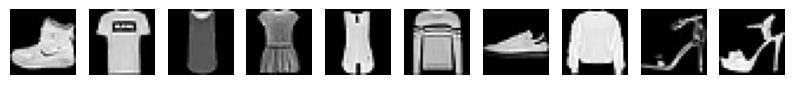

In [9]:
# 첫 10장만 시각화
fig, axs = plt.subplots(1, 10, figsize=(10, 10))
for i in range(10):
  axs[i].imshow(train_input[i], cmap='gray')  # 이미 배경이 검정색..
  axs[i].axis('off')
plt.show()

In [10]:
# 타겟값 확인
for i in range(10):
  print(train_target[i], end = ' ')

9 0 0 3 0 2 7 2 5 5 

In [11]:
# FashionMNIST 의 레이블 의미
# 0      1       2       3      4     5      6     7         8      9
# 티셔츠 바지   스웨터  드레스   코트   샌달   셔츠   스니커즈   가방   앵클부츠

In [12]:
# 각 레이블당 샘플 개수 확인
print(np.unique(train_target, return_counts=True))

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))


In [13]:
# (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
# array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))

# 0 ~ 9 레이블까지 6000개씩 샘플

# 로지스틱 회귀로 분류하기

## 전처리 (정규화)

In [14]:
# 정규화
# 각 픽셀값 0~255 -> 0~1 사이의 값으로 '정규화'
# 양수 값으로만 이루어진 이미지를 전처리 할때 많이 사용하는 방법

train_scaled = train_input / 255.0  # 정규화

# 1차원 배열로 펼치기
train_scaled = train_scaled.reshape(-1, 28 * 28)

train_scaled.shape




(60000, 784)

In [15]:
# 정규화 결과 확인
np.min(train_scaled), np.max(train_scaled)

(np.float64(0.0), np.float64(1.0))

In [16]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import SGDClassifier

In [17]:
sc = SGDClassifier(loss='log_loss', max_iter=5, random_state=42)

scores = cross_validate(sc, train_scaled, train_target, n_jobs=-1)

np.mean(scores['test_score'])

np.float64(0.8194166666666666)

In [18]:
"""
    z = a x (Weight) + b x (Length) + c x (Diagonal) + d x (Height) + e x (Width) + f

    위 식을 FasionMNIST 데이터에 맞게 변형하면 다음과 같을겁니다↓
    클래스별로 방정식

    ▶우선 첫번째 레이블인 '티셔츠' 에 대한 선형방정식

       z_티셔츠 = w1 x (픽셀1) + w2 x (픽셀2) + ... + w784 x (픽셀784) + b

    총 784개의 픽셀, 즉 '특성' 이 있으므로 아주 긴~~식이 만들어 집니다.
    '가중치 (w, weight)' 개수도 많아졌다 . w1 ~ w784.    마지막의 b 는 절편 (bias)

    ▶다음은 두번째 레이블인 '바지' 에 대한 선형 방정식

      z_바지 = w1` x (픽셀1) + w2` x (픽셀2) + ... + w784` x (픽셀784) + b`

    이 식은 먼저의 티셔츠에 대한 선형방정식과 매우 비슷하다.
    동일하게 784개의 픽셀값을 그대로 사용한다
    다만! 바지에 대한 출력을 계산하기 위해 가중치와 절편은 다른 값을 사용해야 한다.
    티셔츠와 같은 가중치를 사용한다면 바지와 티셔츠를 구분할 수 있을리가 없다.

    이런 식으로 나머지 클래스에 대한 선형 방정식을 모두 생각해 볼수 있습니다.
    SGDClassifier 모델을 FasionMNIST 데이터의 클래스를 가능한 잘 구분할수 있도록
    '10개의 방정식' 에 대한 모델 파라미터(가중치와 절편) 을 찾습니다.
"""
None

# 인공신경망으로 분류하기

In [19]:
# 인공신경망에서는 '교차검증' 을 잘 사용하지 않고 검증 세트를 별도로 덜어내어 사용하곤 함.
#    - 이유1 :  딥러닝 분야의 데이터셋은 이미 충분히 크다.  (검증 점수가 안정적)
#    - 이유2 :  교차검증 수행하기에 훈련시간이 너무 오래 걸린다.


In [20]:
from sklearn.model_selection import train_test_split

In [21]:
train_scaled, val_scaled, train_target, val_target = \
  train_test_split(train_scaled, train_target, test_size=0.2, random_state=42)

In [22]:
print(train_scaled.shape, train_target.shape)
print(val_scaled.shape, val_target.shape)

(48000, 784) (48000,)
(12000, 784) (12000,)


### Dense Layer
밀집층

![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSv2ABGkovif5KFtoEY0cDegI-H8GK2GHU03MNYB8q4Xg&s)

In [23]:
# keras.layers 패키지 안에는 다양한 층(layer) 이 준비되어 있다.

In [24]:
#  (784 + 1) x 10 = 7850 개의 연결된 선!  빽빽하다 -> Dense Layer
#  양쪽 층이 '모두' 연결되어 있기 때문에  -> Fully Connected Layer (완전 연결층) 이라고도 한다


![](https://epynn.net/_images/Dense-01.svg)

**Input**

https://www.tensorflow.org/api_docs/python/tf/keras/Input
```python
tf.keras.Input(
    shape=None,  # 입력 shape
    batch_size=None,
    dtype=None,
    sparse=None,
    batch_shape=None,
    name=None,
    tensor=None
)
```

**Dense**

https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense

```python
tf.keras.layers.Dense(
    units,  # 뉴런개수
    activation=None,  # 출력에 적용할 활성화 함수
    use_bias=True,
    kernel_initializer='glorot_uniform',
    bias_initializer='zeros',
    kernel_regularizer=None,
    bias_regularizer=None,
    activity_regularizer=None,
    kernel_constraint=None,
    bias_constraint=None,
    lora_rank=None,
    **kwargs
)
```

In [25]:
# 입력층
# shape=(784,) : 입력의 크기
inputs = keras.Input(shape=(784,))

# Dense (뉴런개수, 뉴런의 출력에 적용할 활성화 함수)
dense = keras.layers.Dense(units=10, activation='softmax')

# units=10 : 패션이미지를 분류하는 문제 (10개의 클래스)
# activation='softmax': 출력값을 확률값으로 변환 (다중분류문제)


## 모델 생성

keras 의 Sequential 클래스 사용하여 모델 생성

**Sequential**

https://www.tensorflow.org/api_docs/python/tf/keras/Sequential

```python
tf.keras.Sequential(
    layers=None,
    trainable=True,
    name=None
)
```

In [26]:
model = keras.Sequential(layers=[inputs, dense])

## compile()

In [27]:
# keras 모델 훈련전 모델 설정 단계
# compilie()
#     loss=  손실함수 지정 (★필수!)
#     metrics= 훈련과정에서 계산하고픈 측정값

**compile()**

https://www.tensorflow.org/api_docs/python/tf/keras/Model#compile

```python
compile(
    optimizer='rmsprop',
    loss=None,
    loss_weights=None,
    metrics=None,
    weighted_metrics=None,
    run_eagerly=False,
    steps_per_execution=1,
    jit_compile='auto',
    auto_scale_loss=True
)
```

In [28]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

### loss=

In [29]:
# 어떤 손실함수를 사용하나?
#                                             keras 에선 이렇게 나누어 부른다
#  이진분류 : 이진 크로스 엔트로피 손실 함수 사용  ->  loss='binary_crossentropy'
#  다중분류 : 크로스 엔트로피 손실 함수 사용      -> loss='categorical_crossentropy'

In [30]:
# 이진분류 문제에서
# 이진 크로스 엔트로피 손실을 위해 -log(예측 확률) x 타겟값(정답)

# 출력층 출력값을 a 라 할때 크로스 엔트로피 는 다음과 같이 계산.

#  양성샘플 (타겟값1) 인 경우   -log(a) x 타겟값
#  음성샘플 (타겟값0) 인 경우   -log(1-a) x (1-타겟값)

# 이진분류의 경우는 오직 양성클래스에 대한 확률(a)  만 출력하니까 계산이 간단했다.

In [31]:
# 다중분류의 경우.

# 그러나 FashionMNIST 는?
#                                 one-hot encoding
# 샘플이 티셔츠일 확률 a1             ↓
#  a1  ---->   -log(a1) x 타겟값      1   --> -log(a1)

#  a2  ---->   -log(a2) x 타겟값      0
#  .. ....     ..                    ...
#  a10  ---->   -log(a10) x 타겟값    0

In [32]:
# 다중분류에서 크로스 엔트로피 손실 함수를 사용하려면
#  0, 1, 2.. 와 같이 정수로 된 타겟 값을 원-핫 인코딩으로 변환해야 한다.


In [33]:
train_target[:10]

array([7, 3, 5, 8, 6, 9, 3, 3, 9, 9], dtype=uint8)

In [34]:
# 원래는(?) one-hot encding 해야 하나..
# TF 에서는 정수로 된 타겟값을 one-hot encoding 으로 바꾸지 않고 그대로 사용 가능.

# 정수로 된 카겟값을 사용하여 크로스 엔트로피 손실을 계산하는것이 바로
#    => sparse_categorical_crossentropy 다.

# ※ 만약에 타겟값은 one-hot encoding 으로 준비했다면
#   손실함수를 loss='categorical_crossentropy' 로 지정한다.

### metrics=

In [35]:
# keras 는 모델훈련시 epoch 마다 loss 값 출력.
# loss 값이 줄어드는것 뿐 아니라, metrics 에 명시한 accuracy 도 함께 출력함.

## fit()

https://www.tensorflow.org/api_docs/python/tf/keras/Model#fit

```python
fit(
    x=None,
    y=None,
    batch_size=None,
    epochs=1,
    verbose='auto',
    callbacks=None,
    validation_split=0.0,
    validation_data=None,
    shuffle=True,
    class_weight=None,
    sample_weight=None,
    initial_epoch=0,
    steps_per_epoch=None,
    validation_steps=None,
    validation_batch_size=None,
    validation_freq=1
)
```

In [36]:
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7370 - loss: 0.7853
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8346 - loss: 0.4845
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8452 - loss: 0.4564
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8504 - loss: 0.4425
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8537 - loss: 0.4337


In [37]:
"""
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8537 - loss: 0.4337

  ↑ Epoch, Batch, 시간, step, accuracy, loss,
"""
None

In [38]:
# keras 는 mini-batch 사용
#  기본 배치 크기는 32개
#  훈련데이터 크기 48000개 -> 1500개의 배치

# step : 한번의 batch 를 수행하고 weight 업데이트 계산하는 단위.
#    - 세션 내에서 '순전파 → 역전파 →  가중치갱신'이라는 하나의 과정이 일어난 횟수
#    - Iteration Step 등으로 불리기도 한다

## evaluate()

https://www.tensorflow.org/api_docs/python/tf/keras/Model#evaluate

```python
evaluate(
    x=None,
    y=None,
    batch_size=None,
    verbose='auto',
    sample_weight=None,
    steps=None,
    callbacks=None,
    return_dict=False,
    **kwargs
)
```

In [39]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8462 - loss: 0.4364


[0.4444445073604584, 0.8458333611488342]

In [40]:
"""
▶사이킷런 모델
                               손실 함수      반복 횟수
                                   ↓             ↓
모델 → sc = SGDClassifier ( loss = ' log ' , max_iter = 5 )
훈련 → sc.fit ( train_scaled , train_target )
평가 → sc.score ( val_scaled , val_target )

▶케라스 모델
                          층 생성
                                ↓
     dense = keras.layers.Dense(10 , activation = ' softmax ')

모델 →  model = keras.Sequential ( dense )
                                   손실 함수
        model.compile (loss='sparse_categorical_crossentropy', metrics = 'accuracy ' )
훈련 →  model.fit ( train_scaled , train_target , epochs = 5 )
평가 →  model.evaluate ( val_scaled , val_target )   ↑반복 횟수
"""
None

# 심층신경망 (DNN: Deep Neural Network)
여러개의 hidden layer 추가

## 은닉층 (hidden layer)
- 입력층과 출력층 사이의 레이어(들)

In [41]:
# ppt 참조

## 활성화 함수 (activation function)

In [42]:
# 활성화 함수 (activation function)
#  : 선형방정식 계산결과에 적용되는 함수

#  출력층에 적용되는 활성화 함수는 제한적
#       이진분류 -> 시그모이드 함수,  다중분류는 -> 소프트 맥스   ★(분류모델에서 쓰는 활성화 함수)

#  반면, 은닉층에 적용되는 활성화 함수는 다양하다!
#       sigmoid, ReLu, Tanh...

In [43]:
# 참고] 회귀모델에 출력층에 사용하는 활성화 함수? => '필요없다!'
#    회귀의 출력은 '임의의 숫자'이기 때문에.
#    출력층의 선형방정식 계산결과를 그대로 출력.
#    이 경우 Dense layer 의 activation= 매개변수에 값을 지정하지 않습니다.

### 왜 활성화 함수를 사용하나 ?

In [44]:
"""
  은닉층에는 왜 활성화 함수 필요한가?

  2개의 선형방정식을 생각해보자
      a x 4 + 2 = b

      b x 3 - 5 = c

    b 대신에 위의 식을 대입하면 -> a x 12 + 1 = c

    이렇게 합치면 b 가 사라진다!

  신경망도 마찬가지.  은닉층에서 선형적인 '산술계산만' 수행한다면 수행역할이 없는 셈이 된다.
  선형계산을 적당하게 비선형적으로 비틀어 주어야 한다.

  가령.
      a x 4 + 2 = b
          ↓
        lob(b) = k
          ↓
      k x 3 - 5 = c
"""
None

## layer(들) 만들기

In [45]:
inputs = keras.Input(shape=(784,))
dense1 = keras.layers.Dense(100, activation='sigmoid')  # 시그모이드 활성화 함수를 사용한 은닉층
dense2 = keras.layers.Dense(10, activation='softmax')  # 소프트맥스 활성화 함수를 사용한 출력층

In [46]:
# 은닉층의 뉴런의 개수는? <- 경험과 실험을 통해 알아 나가야 됨.
# 출력층의 뉴런개수보다는 많아야 함!!


## DNN 만들기

In [47]:
model = keras.Sequential([inputs, dense1, dense2])

In [48]:
# summary()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                      │ (None, 100)                 │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

## 모델 파라미터의 개수

In [49]:
# dense1 의 parameter
#     78500  =  (입력 784  + bias) x 100

# dense2 의 parameter
#      1010  =  (입력 100 + bias) x 10

## layer를 추가하는 다른 방법들
Sequential 클래스에 layer 를 추가하는 방법들

In [50]:
model = keras.Sequential([
  keras.Input(shape=(784,)),
  keras.layers.Dense(100, activation='sigmoid', name='hidden'),  # layer 이름
  keras.layers.Dense(10, activation='softmax', name='output'),
], name='Fashion MNIST 모델')  # 모델 이름

model.summary()


Model: "Fashion MNIST 모델"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ hidden (Dense)                       │ (None, 100)                 │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
# add() 사용하는 방법
model = keras.Sequential()
model.add(keras.Input(shape=(784,)))
model.add(keras.layers.Dense(100, activation='sigmoid', name='hidden'))
model.add(keras.layers.Dense(10, activation='softmax', name='output'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ hidden (Dense)                       │ (None, 100)                 │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

## compile & fit

In [52]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7487 - loss: 0.7827
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8459 - loss: 0.4272
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8597 - loss: 0.3874
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8688 - loss: 0.3620
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8760 - loss: 0.3427


In [53]:
# 이전의 단일 layer 로 했을때와 비교해보자.
# accuracy 는 증가했고, loss 감소
# 학습시간을 더 걸렸다.

In [54]:
# 기존의 sigmoid 활성화 함수의 문제점 --> 기울기소실 (vanishing gradient) 문제

![](https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2FokTU1%2FbtrCH4Fx7Ro%2Fm5f9UkRkl7CP3dUEgXTtk1%2Fimg.png)

# ReLU 활성화 함수

![](https://blog.kakaocdn.net/dn/vgJna/btqQzRGmwcO/TK3KTMlz4CYag8rBTKfYkK/img.png)

ReLU : '렐루'

In [55]:
# ↑ 이미지 분류에 많이 사용된는 활성화 함수.

# Flatten layer

In [56]:
# Flatten layer
#   batch 차원을 제외하고 나머지 입력차원을 모두 일렬로 펼치는 역할
#   입력에 곱해지는 가중치나 절편은 없다.
#   즉 모델 파라미터 없고, 학습하는 층이 아니라 -> 모델의 성능에 영향을 주는 레이어는 아니다

In [57]:
model = keras.Sequential()
model.add(keras.layers.Input(shape=(28, 28)))
model.add(keras.layers.Flatten())  # (28, 28) => (784,)
model.add(keras.layers.Dense(100, activation='relu'))  # 활성화 함수 relu
model.add(keras.layers.Dense(10, activation='softmax'))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 100)                 │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
"""
↑ 첫번째 Flatten 클래스에 포함된 모델 파라미터는 0 이다!

keras 의 Flatten 층을 신경망 모델에 추가함으로 얻는 장점은
=>  '입력값의 차원' 을 짐작할수 있다는 점입니다.

앞의 출력에서 784개의 입력이 첫번째 은닉층에 전달된다는 것을 알수 있습니다.
이는 이전에 만들었던 모델에서는 쉽게 눈치채기 어려웠습니다.  (앞선 summary 결과와 대조해보자)

>> '입력데이터에 대한 전처리 과정'을 가능한 모델에 포함시키는 것이 keras API 철학중 하나입니다.

"""
None

## 입력데이터 다시 준비

In [59]:
# 입력데이터를 다시 준비하자 (28, 28)

In [60]:
(train_input, train_target), (test_input, test_target) = \
              keras.datasets.fashion_mnist.load_data()

train_scaled = train_input / 255.0

train_scaled, val_scaled, train_target, val_target = \
  train_test_split(train_scaled, train_target, test_size=0.2, random_state=42)

In [61]:
train_scaled.shape

(48000, 28, 28)

In [62]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7620 - loss: 0.6761
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8519 - loss: 0.4068
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8689 - loss: 0.3599
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8786 - loss: 0.3351
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8865 - loss: 0.3165


In [63]:
# ↑ sigmoid 함수를 사용했을때보다 ReLU 함수를 사용햇을때가 더 좋은 결과!

In [64]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8624 - loss: 0.3927


[0.3927798569202423, 0.8610000014305115]

# 인공신경망의 하이퍼 파라미터들

In [65]:
# '하이퍼 파라미터'
#   모델이 학습하는 파라미터 가 아니다
#   학습전에 사람이 지정해 주어야 하는 파라미터다.

# 인공신경망에서의 하이퍼 파라미터들은 많~다
#   (지금까지 배운 범위 에선 다음과 같은 하이퍼 파라미터 들이 있다)
#   - 추가할 은닉층의 개수
#   - 각 층의 뉴런 개수
#   - 활성화 함수
#   - 층의 종류
#   - 배치(batch) 사이즈 : fit() 의 batch_size= 매개변수
#   - epoch : fit()  의 epochs= 매개변수

# Optimizer
- 옵티마이저,
- keras 가 제공하는 경사하강법 알고리즘(들)

In [66]:
# keras 는 기본적으로 '미니배치 경사하강법' 을 사용한다

#  미니배치(mini-batch) 의 개수 기본값은 32개 입니다
#  fit() 의 batch_size= 매개변수에서 이를 조정해줄수 있다

#  경사하강법 알고리즘은
#  compile() 의 optimizer= 매개변수에서 이를 설정해줄수 있다
#  기본값은 RMSprop 사용.

# keras 는 다양한 종류의 경사하강법 알고리즘 제공하며
#   이를 옵티마이저 (optimizer) 라 한다
# 어떠한 옵티마이저 를 선택할른지도 하이퍼 파라미터다.

# 경사하강법 알고리즘의 학습률(learning rate) 파라미터 또한 조정가능한 하이퍼 파라미터다.

- Convex function (볼록 함수)

![](https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2FqQ8wX%2FbtrClmTlA7P%2FDPYMsPcWqAUrMiKnk0oAUk%2Fimg.png)

- Non-convex function (비볼록 함수)

![](https://blog.kakaocdn.net/dn/bi7dC6/btrCokN0IbK/EeSswSjpUAH9ArFqi98uB1/img.gif)

- local minimum

![](https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2FSxaKf%2FbtrCiQ2rVKR%2FcBfOFOoubyevkbzdQNqfV0%2Fimg.png)

- saddle point 문제

![](https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2FdwcRcc%2FbtrClmshN0q%2F4fJGFrTOMfGR2J8S0WF3Zk%2Fimg.png)

- momentum
![](https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2FkEqvr%2FbtrCkKUukCF%2FxLBzKe8UGeolScjr2pF0GK%2Fimg.png)

- learning rate
![](https://www.jeremyjordan.me/content/images/2018/02/Screen-Shot-2018-02-24-at-11.47.09-AM.png)

### SGD optimizer

**tf.keras.optimizers.SGD**

https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/SGD

```python
tf.keras.optimizers.SGD(
    learning_rate=0.01,
    momentum=0.0,
    nesterov=False,
    weight_decay=None,
    clipnorm=None,
    clipvalue=None,
    global_clipnorm=None,
    use_ema=False,
    ema_momentum=0.99,
    ema_overwrite_frequency=None,
    loss_scale_factor=None,
    gradient_accumulation_steps=None,
    name='SGD',
    **kwargs
)
```

In [ ]:
# SGD optimizer 는 확률적 경사하강법 사용
#  그런데 이름에서 풍기는 (Stochastic ..) 것과는 달리
#  1개의 샘플을 뽑아서 훈련하지는 않고,  앞서 언급한 것처럼 이또한 미니배치(mini-batch) 를 사용합니다

In [68]:
model.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [69]:
# 위 optimizer 는
# tensorflow.keras.optimizers 패키지 아래 SGD 클래스에 구현되어 있다
# 위에서처럼 'sgd' 문자열로 지정하면.  SGD 클래스의 기본설정 매개변수로 생성한 객체와 동일하게 생성된다.

# 즉 위의 코드는 아래와 같이 작성한 코드와 정확히 동일하다

sgd = keras.optimizers.SGD()
model.compile(optimizer=sgd,
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])

### learning rate=
학습률

In [ ]:
# learning_rate= 기본값은 0.01
sgd = keras.optimizers.SGD(learning_rate=0.1)

## 다양한 optimizer

In [ ]:
"""

  기본경사 하강법 옵티마이저

      learning_rate=0.01         momentum>0               nesterov=True
            [SGD] ---------------> [모멘텀] ----------> [네스테로프 모멘텀]
                                      │
                                      │
   적응적 학습률 옵티마이저            │
  (Adaptive learning rate)            │
                                      ↓
          [RMSprop]  ------------> [Adam]
                learning_rate=0.001

          [Adagrad]

"""
None

## 기본 경사 하강법 (SGD)

In [ ]:
# momentum= 기본값은 0
#    (사용할 경우 일반적으로 0.9 이상을 사용함 -> 그레디언트 가속도 적용 -> '모멤텀 최적화' 사용)


In [66]:
# nesterov=True 로 주면
# '네스테로프 모멘텀 최적화 (nesterov momentum optimization, 또는 네스테로프 가속 경사)' 를 사용

# 모멘텀 최적화는 '2번 반복'
# 일반적으로 기본모멘텀 최적화보다는 나은 성능 기대


In [70]:
sgd = keras.optimizers.SGD(momentum=0.9, nesterov=True)

### adaptive learning rate (적응적 학습률)
AdaGrad, RMSprop
---
**tf.keras.optimizers.Adagrad**

https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adagrad


```python
tf.keras.optimizers.Adagrad(
    learning_rate=0.001,
    initial_accumulator_value=0.1,
    epsilon=1e-07,
    weight_decay=None,
    clipnorm=None,
    clipvalue=None,
    global_clipnorm=None,
    use_ema=False,
    ema_momentum=0.99,
    ema_overwrite_frequency=None,
    loss_scale_factor=None,
    gradient_accumulation_steps=None,
    name='adagrad',
    **kwargs
)
```

---
**tf.keras.optimizers.RMSprop**

https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/RMSprop


```python
tf.keras.optimizers.RMSprop(
    learning_rate=0.001,
    rho=0.9,
    momentum=0.0,
    epsilon=1e-07,
    centered=False,
    weight_decay=None,
    clipnorm=None,
    clipvalue=None,
    global_clipnorm=None,
    use_ema=False,
    ema_momentum=0.99,
    ema_overwrite_frequency=None,
    loss_scale_factor=None,
    gradient_accumulation_steps=None,
    name='rmsprop',
    **kwargs
)
```


In [66]:
# 모델의 최적점 가까이 갈수록 학습률을 낮추어 나감.
#  => 안정적인 최적점에 수렴할 가능성 높임.
#  => 학습률 매개변수를 튜닝하는 수고를 덜수 있다.

# 대표: AdaGrad ('adagrad'),
#       RMSprop ('rmsprop') (디폴트!)


In [66]:
rmsprop = keras.optimizers.RMSprop()  # <- 생성자에 매개변수 지정해주면된다.
model.compile(optimizer=rmsprop, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [66]:
adagrad = keras.optimizers.Adagrad()  # <- 생성자에 매개변수 지정해주면된다.
model.compile(optimizer=adagrad, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#### Adam 옵티마이저

**tf.keras.optimizers.Adam**

https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam

```python
tf.keras.optimizers.Adam(
    learning_rate=0.001,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07,
    amsgrad=False,
    weight_decay=None,
    clipnorm=None,
    clipvalue=None,
    global_clipnorm=None,
    use_ema=False,
    ema_momentum=0.99,
    ema_overwrite_frequency=None,
    loss_scale_factor=None,
    gradient_accumulation_steps=None,
    name='adam',
    **kwargs
)
```

In [ ]:
# Adam: 모멘텀 최적화 + RMSprop 의 장점을 접목.
#    인공신경망 학습시 '처음' 에 시도해볼 좋은 알고리즘 추천!

In [71]:
set_seed(42)

# 모델 생성
model = keras.Sequential()
model.add(keras.layers.Input(shape=(28, 28)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))

# 모델 컴파일, Adam optimizer 사용
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 모델 학습
model.fit(train_scaled, train_target, epochs=5)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7630 - loss: 0.6753
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8546 - loss: 0.4058
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8692 - loss: 0.3597
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8811 - loss: 0.3282
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8879 - loss: 0.3062


In [72]:
# 검증
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8710 - loss: 0.3616


[0.36296507716178894, 0.8715000152587891]

In [ ]:
# [0.3927798569202423, 0.8610000014305115]

# [0.36296507716178894, 0.8715000152587891]

# RMSprop 보다는 조금 나은 성능.

In [73]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 100)                 │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 238,532 (931.77 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 159,022 (621.18 KB)